# **Machine Learning and Forecasting: Seminar 6**

In [62]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.statespace.tools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_white

**Tutorial: Wisconsin employment time series**

Q1: This case study aims to forecast employment with the dataset **Wisconsin-employment-time-series.csv**, downloaded from https://github.com/PacktPublishing/Practical-Time-Series-Analysis/blob/master/Data%20Files/wisconsin-employment-time-series.csv. With this dataset, estimate an ARMA model to fit the data.

In [6]:
W_employment = pd.read_csv("Datasets/Wisconsin-employment-time-series.csv")

Q2: Provide Python code to perform the hold-out method: define a subset as the training dataset and the rest as the test dataset. <font face="Calibri" size=1.5 color='#3543cd'> Note: You can define the data before a given date as the training dataset and the rest as the test dataset.<font>

In [19]:
observation_count = len(W_employment)
train = W_employment[:(observation_count-46)]
test = W_employment[(observation_count-46):]

In [20]:
len(train), len(test)

(132, 46)

Q3: To check whether your time series is stationary or not, we can perform the Augmented Dickey-Fuller unit root test. Perform the Augmented Dickey-Fuller unit root test on the whole dataset in Q1. Interpret the result. <font face="Calibri" size=1.5 color='#3543cd'> Note: You are referred to https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html regarding the use of the function `adfuller`. Once you have imported the library `from statsmodels.tsa.stattools import adfuller`, you can simply perform the augmented Dickey-Fuller test by `adfuller(data)`, whete "data" is the time series you are to analyse. <font>

In [23]:
W_employment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       178 non-null    object 
 1   Employment  178 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.9+ KB


In [25]:
print(f" The p value of the Augmented Dickey_fuller test is: {adfuller(W_employment["Employment"])[1]}")

 The p value of the Augmented Dickey_fuller test is: 0.9810000189539195


Greater than 0.05 so conclude non stationary (fail to reject null hypothesis).

Q4:  Provide Python code to display the time plot of *Employment*. Interpret the plots. <font face="Calibri" size=1.5 color='#3543cd'> Note: This question shares similarity with Q2 in Seminar 5. <font>

<function matplotlib.pyplot.show(close=None, block=None)>

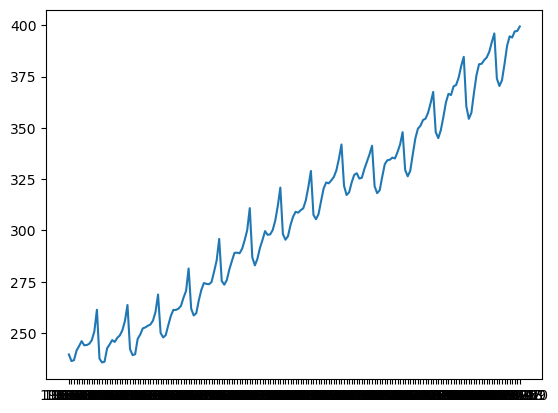

In [26]:
plt.plot(W_employment["Month"], W_employment["Employment"])
plt.show

Q5:  Provide Python code to display the ACF (Autocorrelation) and PACF (Partial Autocorrelation) plots of *Employment*, respectively. Interpret the plots. <font face="Calibri" size=1.5 color='#3543cd'> Note: This question shares similarity with Q2 in Seminar 5. <font>

Text(0.5, -0.15, 'Figure 6.3: PACF.')

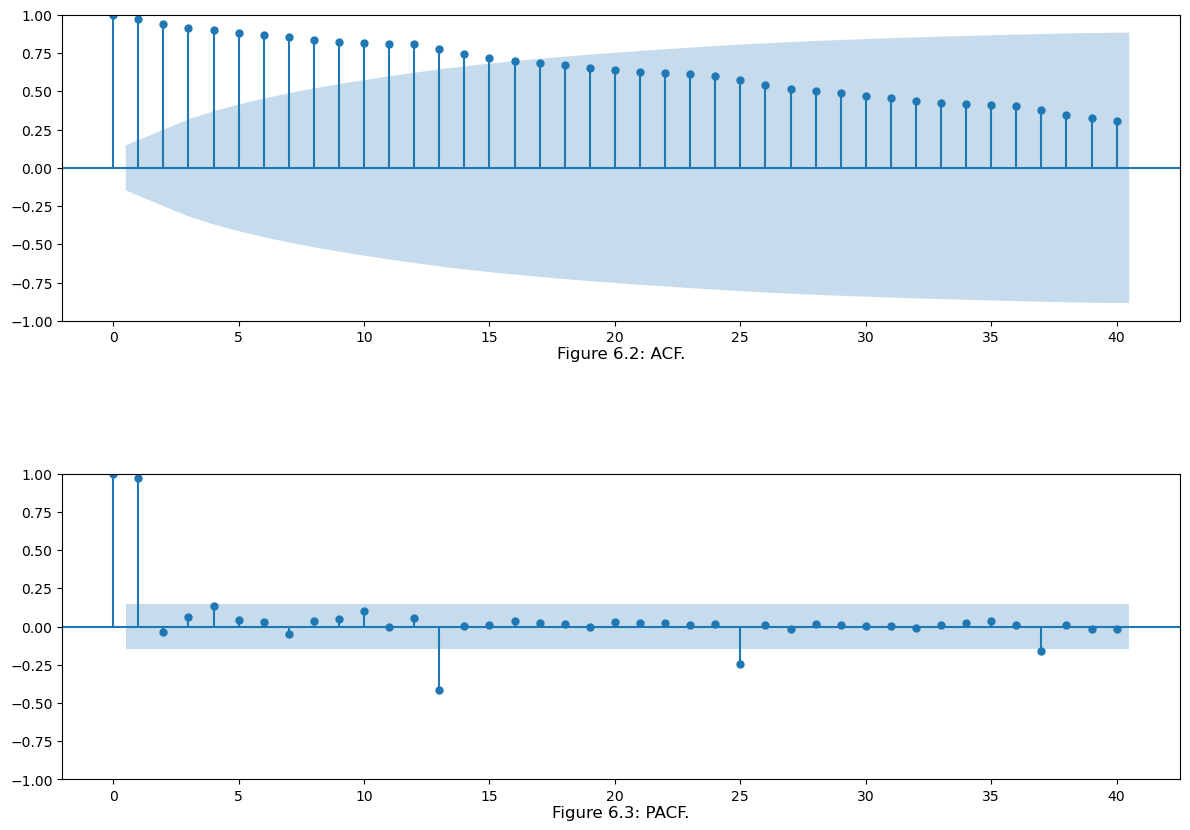

In [33]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(W_employment['Employment'], lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("Figure 6.2: ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(W_employment['Employment'], lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("Figure 6.3: PACF.",y=-0.15)			                  # to add a caption on to the plot

Q6: Provide Python code to perform a logarithematic transformation on the time series and display the time plot of the transformed time series. Interpret the plot. <font face="Calibri" size=1.5 color='#3543cd'> You need to apply ` log_transformation` to transfer the time series. <font>

In [35]:
W_employment["log_Employment"] = np.log(W_employment["Employment"])

In [36]:
W_employment

,Month,Employment,log_Employment
0,1961-01,239.6,5.478971
1,1961-02,236.4,5.465525
2,1961-03,236.8,5.467216
3,1961-04,241.5,5.486869
4,1961-05,243.7,5.495938
...,...,...,...
173,1975-06,394.6,5.977873
174,1975-07,394.0,5.976351
175,1975-08,397.0,5.983936
176,1975-09,397.2,5.984440


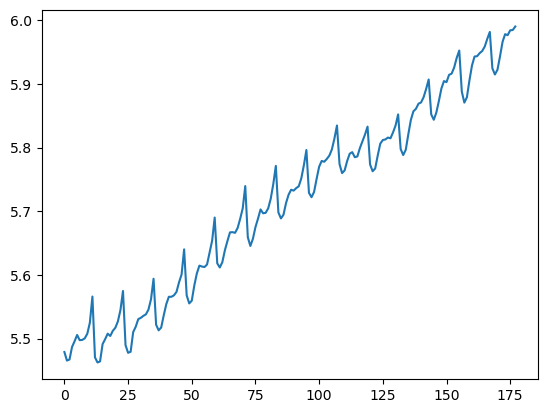

In [43]:
plt.plot(W_employment["log_Employment"])

Q7: Write Python code to apply the first order differencing to the transfered *Employment*  from Q6 and display the time plot of the transformed time series. Interpret the plot. <font face="Calibri" size=1.5 color='#3543cd'> You need to apply ` statsmodels.tsa.statespace.tools.diff`, which needs `import statsmodels.tsa.statespace.tools`, to perform differencing on your time series. <font> `Inline code`

In [48]:
trans_diff1 = statsmodels.tsa.statespace.tools.diff(W_employment["log_Employment"], k_diff=1)

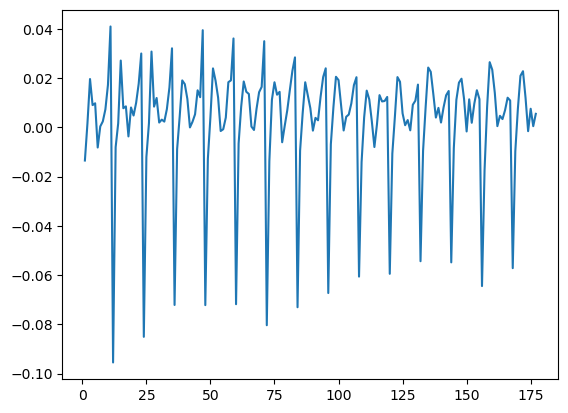

In [49]:
plt.plot(trans_diff1)

Q8: Provide Python code to apply seasonal differencing on the transfered *Employment" from Q7 and display the time plot of the transformed time series. Interpret the plot. <font face="Calibri" size=1.5 color='#3543cd'> You need to apply `statsmodels.tsa.statespace.tools.diff`, which needs `import statsmodels.tsa.statespace.tools` and needs `seasonal_periods=12` to be set in `statsmodels.tsa.statespace.tools.diff`, to perform differencing on your time series. <font>.

In [50]:
trans_diff1_seasonaldiff1 = statsmodels.tsa.statespace.tools.diff(trans_diff1, k_seasonal_diff=1, seasonal_periods=12)

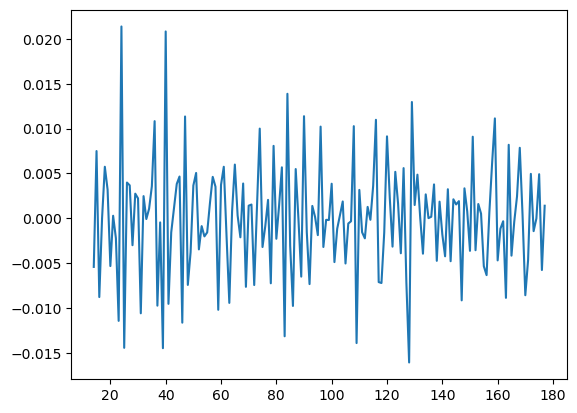

In [51]:
plt.plot(trans_diff1_seasonaldiff1)

Q9: Provide Python code to generate the ACF and PACF of the transfermed time series Q8. Interpret your ACF and PACF plots, respectively. You may ask questions such as "is the time series stantionary?" Should an AR model or a MA model be used to fit the time series? <font face="Calibri" size=1.5 color='#3543cd'> Note: you need function `sm.graphics.tsa.plot_acf` and `sm.graphics.tsa.plot_pacf` to create ACF and PACF plots. The relevent library is `import statsmodels.api as sm `.<font>

Text(0.5, -0.15, 'Figure 6.3: PACF.')

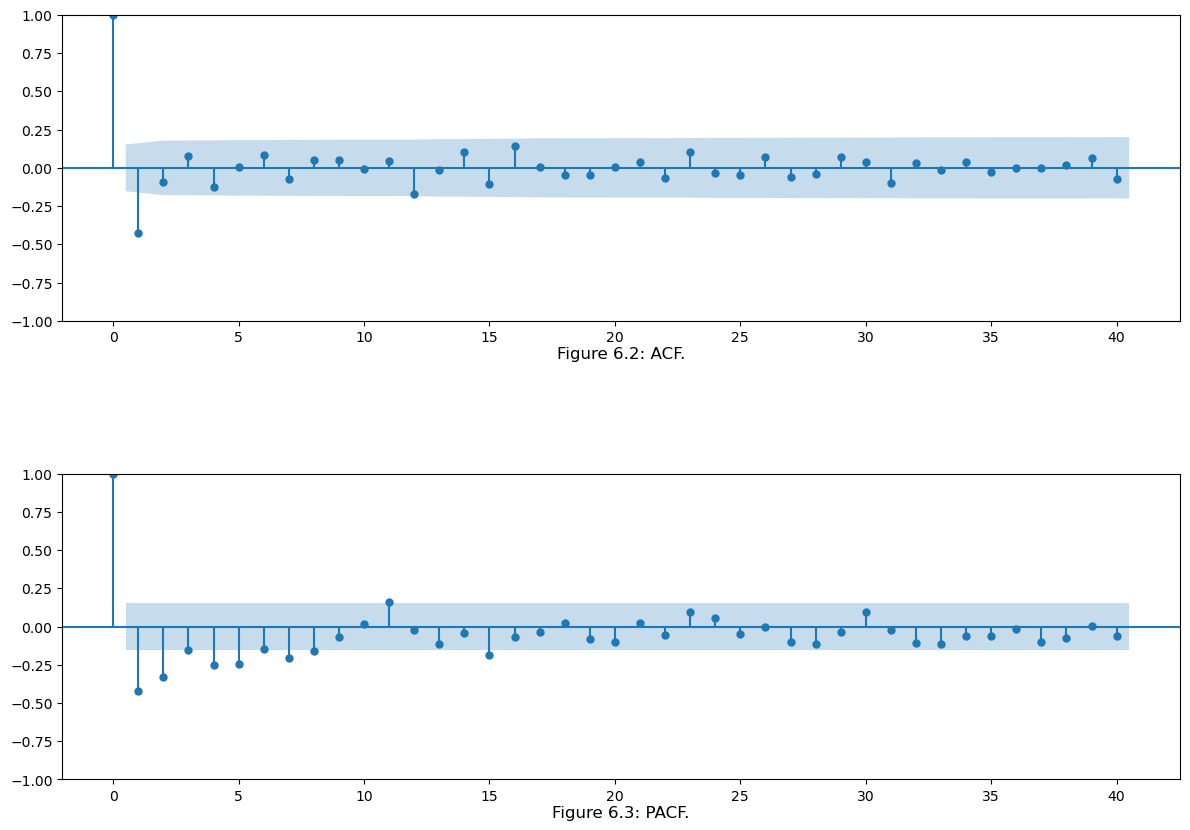

In [52]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(trans_diff1_seasonaldiff1, lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("Figure 6.2: ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(trans_diff1_seasonaldiff1, lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("Figure 6.3: PACF.",y=-0.15)			                  # to add a caption on to the plot

Q10: Provide Python code to learn an AR(2) model and output the values of AIC and BIC of the model, respectively. Check whether your model is statistically significant.<font face="Calibri" size=1.5 color='#3543cd'> Note: you need function `ARIMA(sd_W_Employment, order=(2, 0, 0)).fit()`. The relevent library is `from statsmodels.tsa.arima.model import ARIMA`.<font>

In [56]:
arima_model_2_0_0 = ARIMA(trans_diff1_seasonaldiff1, order=(2, 0, 0)).fit()
print(arima_model_2_0_0.params)	

const    -0.000036
ar.L1    -0.557741
ar.L2    -0.326493
sigma2    0.000029
dtype: float64


In [58]:
residuals = arima_model_2_0_0.resid
sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)	  #to provide the Ljung-Box test

print(arima_model_2_0_0.aic, arima_model_2_0_0.bic)				                    #to provide the AIC and BIC of the model
print(arima_model_2_0_0.summary())	

-1240.1235353403108 -1227.724069629014
                               SARIMAX Results                                
Dep. Variable:         log_Employment   No. Observations:                  164
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 624.062
Date:                Mon, 16 Feb 2026   AIC                          -1240.124
Time:                        14:24:21   BIC                          -1227.724
Sample:                             0   HQIC                         -1235.090
                                - 164                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.566e-05      0.000     -0.158      0.874      -0.000       0.000
ar.L1         -0.5577      0.067     -8.334      0.000      -0.689      -0.427
ar.L2        

Q11: Perform White's test to test whether the residuals appear heteroskedastic.

In [63]:
# -----------------------------
# 3. Prepare regressors for White test
# White test requires exogenous variables.
# For ARMA residuals, we typically regress on fitted values.
# -----------------------------
fitted_vals = arima_model_2_0_0.fittedvalues

# Add constant term
X = sm.add_constant(fitted_vals)

white_test = het_white(residuals, X)

lm_stat = white_test[0]
lm_pvalue = white_test[1]
white_statistic = white_test[2]
white_pvalue = white_test[3]

print("White Test Results")
print("------------------")
print(f"LM Statistic: {lm_stat}")
print(f"LM p-value: {lm_pvalue}")
print(f"F-Statistic: {white_statistic}")
print(f"F p-value: {white_pvalue}")

White Test Results
------------------
LM Statistic: 2.366657850058434
LM p-value: 0.3062575314213888
F-Statistic: 1.17869218315717
F p-value: 0.31032156408209444


Q12: Provide Python code to generate the ACF and PACF of the residuals of the model you have selected from Q10. Interpret your ACF and PACF plots, respectively. <font face="Calibri" size=1.5 color='#3543cd'> Note: you need function `sm.graphics.tsa.plot_acf` and `sm.graphics.tsa.plot_pacf` to create ACF and PACF plots. The relevent library is `import statsmodels.api as sm `.<font>

Text(0.5, -0.15, 'Figure 6.3: PACF.')

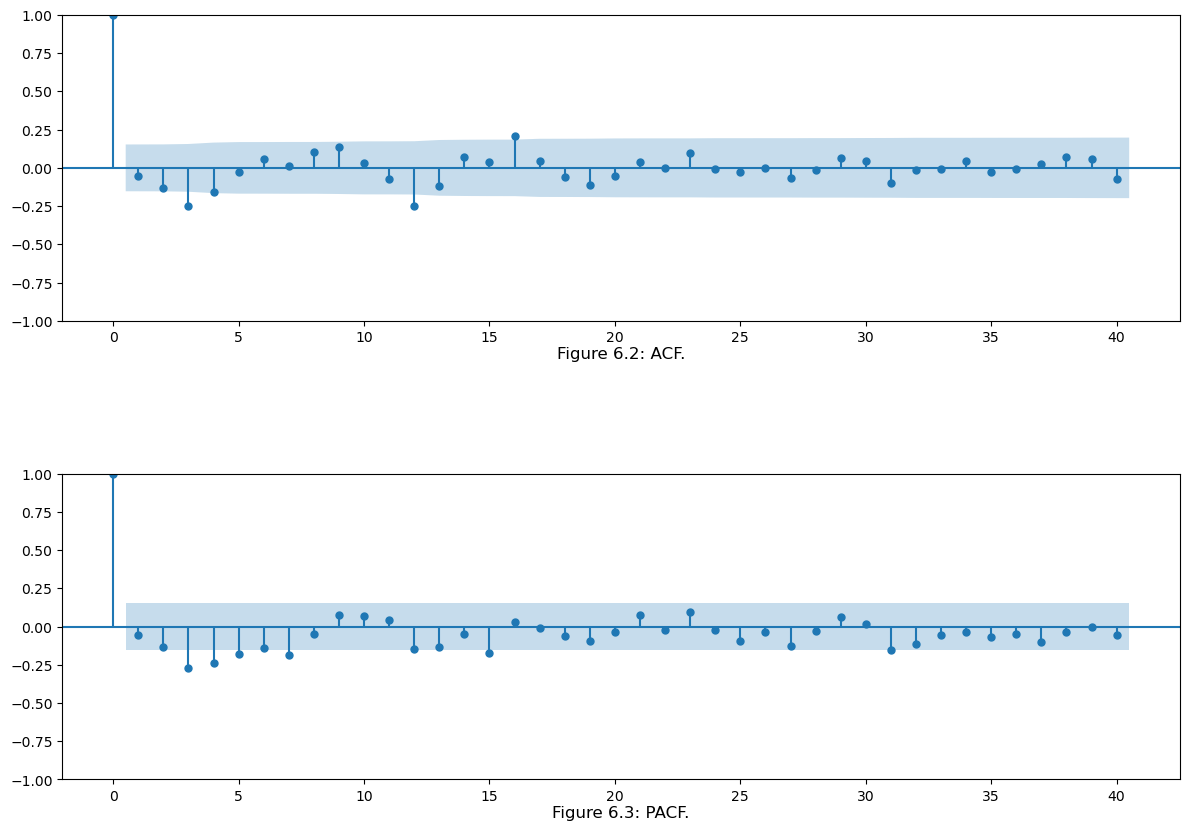

In [64]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(residuals, lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("Figure 6.2: ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(residuals, lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("Figure 6.3: PACF.",y=-0.15)		

Q13：Which model would you select? why?

# Part B---Case study 1: Forecasting electricity consumption
<font face="Calibri" color='#3543cd'> Forecasting electricity consumption is essential for ensuring grid stability, optimizing energy production, and reducing operational costs. It enables utilities to prevent blackouts, plan infrastructure investments, manage market volatility, and efficiently integrate renewable energy sources. Accurate forecasts directly influence economic efficiency and national security.  Today's seminar aims to estimate a time series forecasting model for the above purpose.
<font>

Read the dataset *england_wales_electricity_demand_Three_Months_2024.csv* into Python. The dataset is a subset of the dataset collected from https://www.kaggle.com/datasets/albertovidalrod/electricity-consumption-uk-20092022, which are electricity demand in Great Britain from 2009 (until December 2024). National Grid ESO is the electricity system operator for Great Britain. They have gathered information of the electricity demand in Great Britain from 2009. This is updated twice an hour, which means 48 entries per day. This makes this dataset ideal for time series forecasting.

Once you have answer each question in Part A, you will be able to study this case.

# Part B---Case study 2: Forecasting the number of passengers

Read the dataset *air-passenger-time-series.csv* into Python. The detailed description of this dataset can be found on https://www.kaggle.com/datasets/ashfakyeafi/air-passenger-data-for-time-series-analysis. Based on this dataset, answer the nine questions in Part A.


## Summary
- Understand the method of statistical test for stationarity;
- Understand the Box-Jenkins time series modelling method.


## Suggested reading for the Next Lecture
- To review the following sections/chapter in the book Raschka, S., & Mirjalili, V. (2019). Python machine learning: Machine learning and deep learning with Python, scikit-learn, and TensorFlow 2. Packt publishing ltd:
   1. Chapter 11.
- Alternatively, you can review the following sections/chapter in the book An Introduction to Statistical Learning: with Applications in Python (Springer Texts in Statistics)
   1. Section 12.4
